# 

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/life-style-data/Final_data.csv
/kaggle/input/life-style-data/meal_metadata.csv


In [2]:
import pandas as pd

In [3]:
lifestyle_df= pd.read_csv('/kaggle/input/life-style-data/Final_data.csv')
lifestyle_df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,...,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin
0,34.91,Male,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,Strength,...,2139.59,0.500432,1.624789,0.741237,0.835985,725.10,47.777394,685.1600,7.260425e+19,Medium
1,23.37,Female,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,HIIT,...,1711.65,0.500850,1.514093,0.551247,0.734270,-232.91,40.809803,978.6184,1.020506e+20,High
2,33.20,Female,58.98,1.67,175.04,123.95,54.96,0.91,802.26,Cardio,...,1965.92,0.500610,1.663445,0.574534,0.708124,805.74,44.635580,654.5266,1.079607e+20,High
3,38.69,Female,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,HIIT,...,1627.28,0.499533,0.862017,0.744155,0.811150,1206.21,63.007432,773.6300,8.987921e+19,High
4,45.09,Male,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,Strength,...,2659.23,0.500581,2.538153,0.668405,0.789751,303.60,43.347504,711.4176,5.264685e+19,Low


In [4]:
lifestyle_df.columns

Index(['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM',
       'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned',
       'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)',
       'Workout_Frequency (days/week)', 'Experience_Level', 'BMI',
       'Daily meals frequency', 'Physical exercise', 'Carbs', 'Proteins',
       'Fats', 'Calories', 'meal_name', 'meal_type', 'diet_type', 'sugar_g',
       'sodium_mg', 'cholesterol_mg', 'serving_size_g', 'cooking_method',
       'prep_time_min', 'cook_time_min', 'rating', 'Name of Exercise', 'Sets',
       'Reps', 'Benefit', 'Burns Calories (per 30 min)', 'Target Muscle Group',
       'Equipment Needed', 'Difficulty Level', 'Body Part', 'Type of Muscle',
       'Workout', 'BMI_calc', 'cal_from_macros', 'pct_carbs', 'protein_per_kg',
       'pct_HRR', 'pct_maxHR', 'cal_balance', 'lean_mass_kg', 'expected_burn',
       'Burns Calories (per 30 min)_bc', 'Burns_Calories_Bin'],
      dtype='object')

In [5]:
lifestyle_filtered=lifestyle_df[['Age','Gender','Weight (kg)','Height (m)','BMI','Workout_Type','Physical exercise','Calories_Burned']]
lifestyle_filtered.head()

,Age,Gender,Weight (kg),Height (m),BMI,Workout_Type,Physical exercise,Calories_Burned
0,34.91,Male,65.27,1.62,24.87,Strength,0.01,1080.90
1,23.37,Female,56.41,1.55,23.48,HIIT,0.97,1809.91
2,33.20,Female,58.98,1.67,21.15,Cardio,-0.02,802.26
3,38.69,Female,93.78,1.70,32.45,HIIT,0.04,1450.79
4,45.09,Male,52.42,1.88,14.83,Strength,3.00,1166.40


In [6]:
lifestyle_gender=lifestyle_filtered.groupby('Gender').agg(
    average_weight=('Weight (kg)','mean'),
    average_height=('Height (m)','mean'),
    total_count=('Gender','value_counts')
    
)
lifestyle_gender

,average_weight,average_height,total_count
Gender,,,
Female,73.781614,1.724006,10028
Male,74.016707,1.722176,9972


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [8]:
number_male_female=lifestyle_filtered['Gender'].value_counts()
number_male_female

Gender
Female    10028
Male       9972
Name: count, dtype: int64

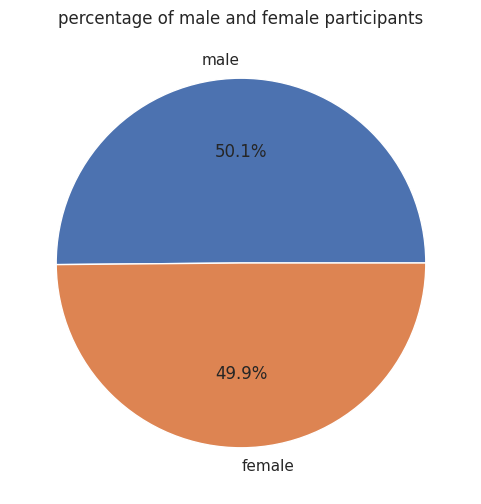

In [9]:
plt.figure(figsize=(6,6))
labels=['male','female']
plt.pie(x=number_male_female.values,labels=labels,autopct='%1.1f%%')
plt.title('percentage of male and female participants')
plt.show()

In [10]:
workout_types=lifestyle_filtered.groupby(['Workout_Type','Gender']).agg(
    average_burned_calories=('Calories_Burned','mean'),
    gender_count=('Gender','value_counts')
)
workout_types

average_burned_calories  gender_count
Workout_Type Gender                                       
Cardio       Female              1215.020773          2418
             Male                1208.189313          2505
HIIT         Female              1645.911355          2479
             Male                1659.112597          2495
Strength     Female              1362.775013          2601
             Male                1360.014595          2470
Yoga         Female               896.823565          2530
             Male                 897.394041          2502

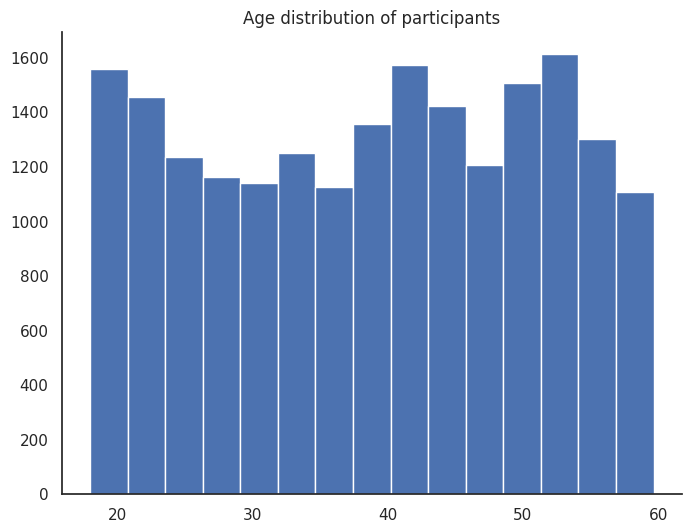

In [11]:
plt.figure(figsize=(8,6))
sns.set_style('white')
plt.hist(x= lifestyle_filtered['Age'],bins=15)
plt.title('Age distribution of participants')
sns.despine()
plt.show()

In [12]:
lifestyle_df.columns

Index(['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM',
       'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned',
       'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)',
       'Workout_Frequency (days/week)', 'Experience_Level', 'BMI',
       'Daily meals frequency', 'Physical exercise', 'Carbs', 'Proteins',
       'Fats', 'Calories', 'meal_name', 'meal_type', 'diet_type', 'sugar_g',
       'sodium_mg', 'cholesterol_mg', 'serving_size_g', 'cooking_method',
       'prep_time_min', 'cook_time_min', 'rating', 'Name of Exercise', 'Sets',
       'Reps', 'Benefit', 'Burns Calories (per 30 min)', 'Target Muscle Group',
       'Equipment Needed', 'Difficulty Level', 'Body Part', 'Type of Muscle',
       'Workout', 'BMI_calc', 'cal_from_macros', 'pct_carbs', 'protein_per_kg',
       'pct_HRR', 'pct_maxHR', 'cal_balance', 'lean_mass_kg', 'expected_burn',
       'Burns Calories (per 30 min)_bc', 'Burns_Calories_Bin'],
      dtype='object')

In [13]:
lifestyle_filtered['Calories_Burned'].max()

2890.82

In [14]:
lifestyle_filtered['Calories_Burned'].min()

323.11

In [15]:
workout_cal= lifestyle_filtered.groupby(['Gender','Workout_Type']).agg(
    min_cal_burned=('Calories_Burned','min'),
    max_cal_burned=('Calories_Burned','max'),
    avg_cal_burned=('Calories_Burned','mean')
).sort_values('avg_cal_burned')
workout_cal

min_cal_burned  max_cal_burned  avg_cal_burned
Gender Workout_Type                                                
Female Yoga                  323.11         1554.59      896.823565
Male   Yoga                  323.99         1569.01      897.394041
       Cardio                440.00         2092.01     1208.189313
Female Cardio                438.80         2087.18     1215.020773
Male   Strength              484.66         2346.27     1360.014595
Female Strength              485.10         2349.89     1362.775013
       HIIT                  603.90         2890.82     1645.911355
Male   HIIT                  604.45         2876.51     1659.112597

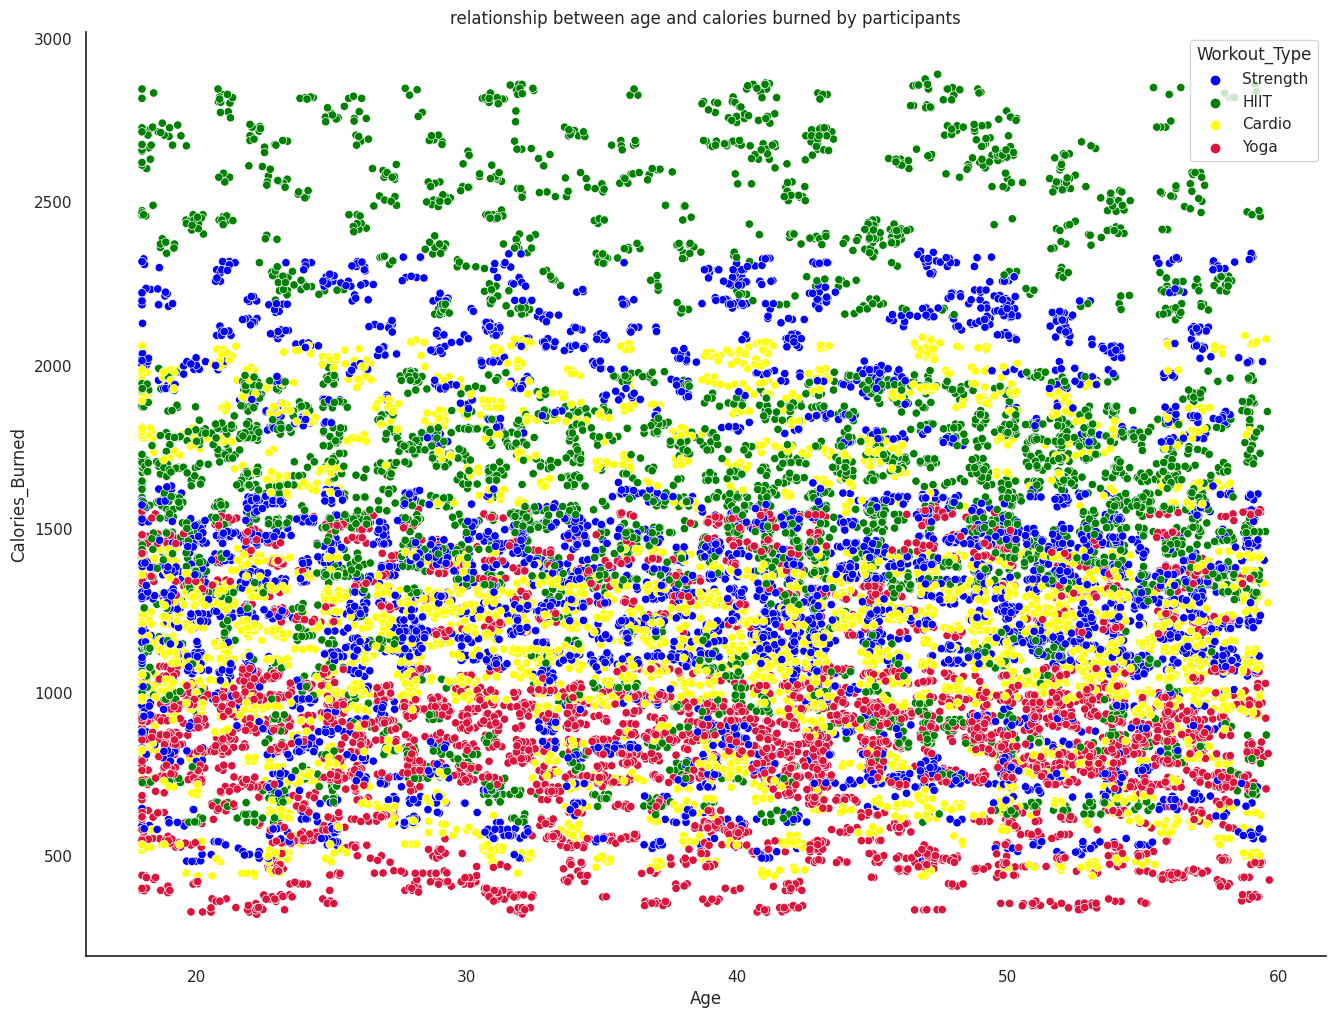

In [16]:
plt.figure(figsize=(16,12))
sns.set_style('white')
labels=['Cardio','HIIT','Strength','Yoga']
sns.scatterplot(x=lifestyle_filtered['Age'],y=lifestyle_filtered['Calories_Burned'],hue=lifestyle_filtered['Workout_Type'],
               palette=['blue','green','yellow','crimson'])
plt.title('relationship between age and calories burned by participants')
sns.despine()
plt.show()


In [17]:
lifestyle_df.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),...,BMI_calc,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,2.000000e+04
mean,38.851454,73.898832,1.723094,179.889702,143.704306,62.195813,1.259446,1280.109600,26.101313,2.627486,...,24.921651,1998.297076,0.499983,1.460142,0.699005,0.802305,744.308699,53.786384,866.352318,8.631802e+19
std,12.114580,21.173010,0.127033,11.510805,14.267688,7.289351,0.341336,502.228982,4.996160,0.604724,...,6.701144,440.848408,0.001455,0.518946,0.144880,0.096613,720.946619,12.498740,250.317069,3.197579e+19
min,18.000000,39.180000,1.490000,159.310000,119.070000,49.490000,0.490000,323.110000,11.333134,1.460000,...,12.037907,1105.570000,0.492434,0.516706,0.371344,0.599789,-1266.220000,30.946261,219.852800,2.491905e+16
25%,28.170000,58.160000,1.620000,170.057500,131.220000,55.960000,1.050000,910.800000,22.387807,2.170000,...,20.094975,1661.022500,0.499054,1.076294,0.583656,0.727676,261.432500,44.587037,714.098250,6.441978e+19
50%,39.865000,70.000000,1.710000,180.140000,142.990000,62.200000,1.270000,1231.450000,25.822504,2.610000,...,24.119097,1943.130000,0.499981,1.382260,0.686284,0.794834,691.190000,51.204908,868.721400,8.371578e+19
75%,49.630000,86.100000,1.800000,189.425000,156.060000,68.090000,1.460000,1553.112500,29.676026,3.120000,...,28.562620,2271.950000,0.500910,1.750495,0.798196,0.869211,1176.290000,61.939016,1012.532700,1.100442e+20
max,59.670000,130.770000,2.010000,199.640000,169.840000,74.500000,2.020000,2890.820000,35.000000,3.730000,...,50.229544,3699.540000,0.507889,3.916881,1.073939,1.047032,3075.580000,90.117371,1477.108800,1.756614e+20


In [18]:
#correlation analysis between bmi and fat percentage
selected_columns=['Age','BMI','Fat_Percentage','Calories_Burned']
df_corr=lifestyle_df[selected_columns]
cor_matrix=df_corr.corr()
cor_matrix

,Age,BMI,Fat_Percentage,Calories_Burned
Age,1.000000,-0.016940,-0.025056,-0.021396
BMI,-0.016940,1.000000,0.902341,-0.004494
Fat_Percentage,-0.025056,0.902341,1.000000,-0.033812
Calories_Burned,-0.021396,-0.004494,-0.033812,1.000000


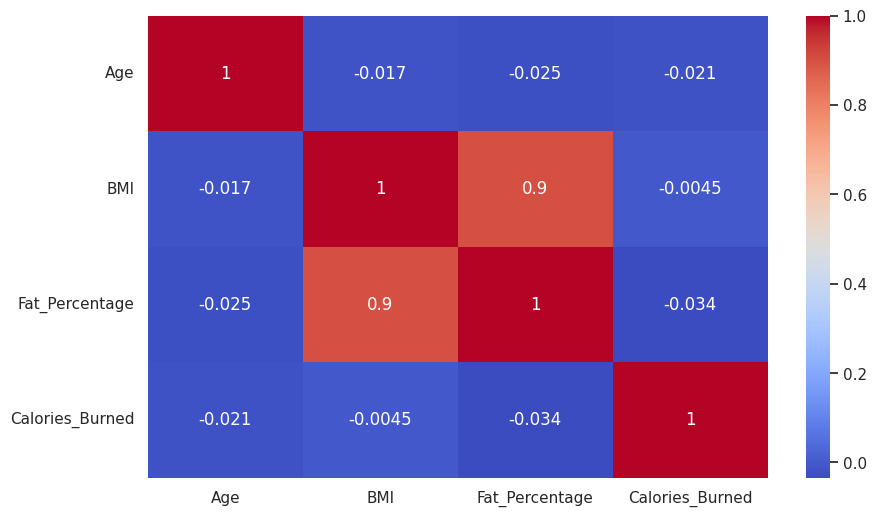

In [19]:
plt.figure(figsize=(10,6))
sns.heatmap(cor_matrix,annot=True,cmap='coolwarm')
plt.show()

In [20]:
lifestyle_filtered['Age'].mean().round(2)

38.85

In [21]:
lifestyle_filtered['Age'].max()

59.67

In [22]:
lifestyle_filtered.columns

Index(['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'BMI', 'Workout_Type',
       'Physical exercise', 'Calories_Burned'],
      dtype='object')

In [23]:
# creating age groups in lifestyle dataframe for further grouping data
bins= [0,18,30,45,60]
lifestyle_df['Age_group']=pd.cut(lifestyle_df['Age'],bins=bins,right=True)
lifestyle_df['Age_group'].unique()

[(30, 45], (18, 30], (45, 60], (0, 18]]
Categories (4, interval[int64, right]): [(0, 18] < (18, 30] < (30, 45] < (45, 60]]

In [24]:
lifestyle_grouped= lifestyle_df.groupby(['Gender','Age_group']).agg(mean_BmI=('BMI','mean'), mean_fat_per=('Fat_Percentage','mean')).round(2)
lifestyle_grouped

/tmp/ipykernel_13/2385098044.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lifestyle_grouped= lifestyle_df.groupby(['Gender','Age_group']).agg(mean_BmI=('BMI','mean'), mean_fat_per=('Fat_Percentage','mean')).round(2)


mean_BmI  mean_fat_per
Gender Age_group                        
Female (0, 18]       25.44         26.03
       (18, 30]      25.37         26.49
       (30, 45]      24.33         25.73
       (45, 60]      24.93         26.07
Male   (0, 18]       25.90         26.53
       (18, 30]      25.48         26.64
       (30, 45]      24.32         25.60
       (45, 60]      25.27         26.28

In [25]:
lifestyle_df.index

RangeIndex(start=0, stop=20000, step=1)

In [26]:
lifestyle_df['Burns_Calories_Bin'].unique()

array(['Medium', 'High', 'Low', 'Very High'], dtype=object)

In [27]:
lifestyle_df['diet_type'].unique()

array(['Vegan', 'Vegetarian', 'Paleo', 'Keto', 'Low-Carb', 'Balanced'],
      dtype=object)

In [28]:
diet_type_count=lifestyle_df['diet_type'].value_counts()
diet_type_count

diet_type
Paleo         3403
Low-Carb      3379
Vegetarian    3337
Keto          3324
Vegan         3323
Balanced      3234
Name: count, dtype: int64

In [29]:
#diet type comparision with age groups in diff gender
diet_age_gen=lifestyle_df.groupby(['Gender','Age_group','diet_type']).agg(number_of_participants=('diet_type','value_counts'))
diet_age_gen

/tmp/ipykernel_13/1184388971.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  diet_age_gen=lifestyle_df.groupby(['Gender','Age_group','diet_type']).agg(number_of_participants=('diet_type','value_counts'))


number_of_participants
Gender Age_group diet_type                         
Female (0, 18]   Balanced                        18
                 Keto                            22
                 Low-Carb                        27
                 Paleo                           24
                 Vegan                           29
                 Vegetarian                      23
       (18, 30]  Balanced                       465
                 Keto                           467
                 Low-Carb                       454
                 Paleo                          471
                 Vegan                          448
                 Vegetarian                     470
       (30, 45]  Balanced                       567
                 Keto                           630
                 Low-Carb                       580
                 Paleo                          582
                 Vegan                          606
                 Vegetarian                     549
       (45, 60]  Balanced                       562
                 Keto                           596
                 Low-Carb                       600
                 Paleo                          636
                 Vegan                          600
                 Vegetarian                     602
Male   (0, 18]   Balanced                        14
                 Keto                            21
                 Low-Carb                        17
                 Paleo                           26
                 Vegan                           24
                 Vegetarian                      20
       (18, 30]  Balanced                       445
                 Keto                           435
                 Low-Carb                       461
                 Paleo                          438
                 Vegan                          457
                 Vegetarian                     458
       (30, 45]  Balanced                       544
                 Keto                           580
                 Low-Carb                       640
                 Paleo                          644
                 Vegan                          544
                 Vegetarian                     630
       (45, 60]  Balanced                       619
                 Keto                           573
                 Low-Carb                       600
                 Paleo                          582
                 Vegan                          615
                 Vegetarian                     585

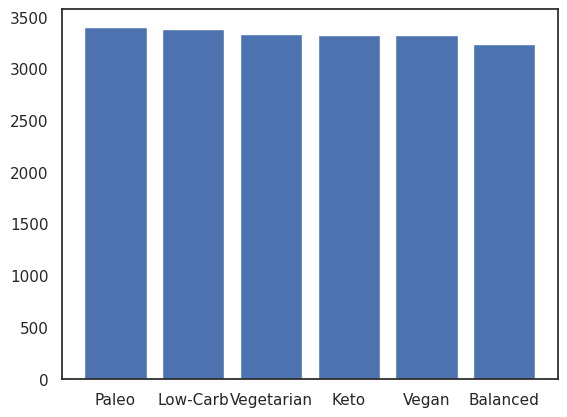

In [30]:
plt.bar(x=diet_type_count.index,height=diet_type_count.values)
plt.show()